In [2]:
pip install kagglehub


   ---------------------------------------- 0/3 [protobuf]
   ---------------------------------------- 0/3 [protobuf]
   ---------------------------------------- 0/3 [protobuf]
   ---------------------------------------- 0/3 [protobuf]
   ---------------------------------------- 0/3 [protobuf]
   ---------------------------------------- 0/3 [protobuf]
   ---------------------------------------- 0/3 [protobuf]
   ---------------------------------------- 0/3 [protobuf]
   ---------------------------------------- 0/3 [protobuf]
   ---------------------------------------- 0/3 [protobuf]
   ---------------------------------------- 0/3 [protobuf]
   ---------------------------------------- 0/3 [protobuf]
   ---------------------------------------- 0/3 [protobuf]
   ---------------------------------------- 0/3 [protobuf]
   ---------------------------------------- 0/3 [protobuf]
   ---------------------------------------- 0/3 [protobuf]
   ------------- -------------------------- 1/3 [kaggle


[notice] A new release of pip is available: 26.0.1 -> 26.2.1
[notice] To update, run: C:\Users\xolmu\AppData\Local\Microsoft\WindowsApps\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\python.exe -m pip install --upgrade pip


In [3]:
import kagglehub

# Download latest version
path = kagglehub.dataset_download("shuvoalok/cityscapes")

print("Path to dataset files:", path)

100%|██████████| 199M/199M [00:09<00:00, 21.8MB/s] 

Extracting files...


Path to dataset files: C:\Users\xolmu\.cache\kagglehub\datasets\shuvoalok\cityscapes\versions\2


In [4]:
import os
import matplotlib.pyplot as plt
from PIL import Image

DATA_DIR = r"C:\Users\xolmu\OneDrive\Desktop\Darslar oyma oy\Computer Vision 2\9 dars\kagglehub\datasets\shuvoalok\cityscapes\versions\2"

train_img_dir = os.path.join(DATA_DIR, "train", "img")
train_label_dir = os.path.join(DATA_DIR, "train", "label")
val_img_dir = os.path.join(DATA_DIR, "val", "img")
val_label_dir = os.path.join(DATA_DIR, "val", "label")

train_images = sorted(os.listdir(train_img_dir))
train_labels = sorted(os.listdir(train_label_dir))

print("Train images:", len(train_images))
print("Train labels:", len(train_labels))
print("Example file:", train_images[0])


Train images: 2975
Train labels: 2975
Example file: train1.png


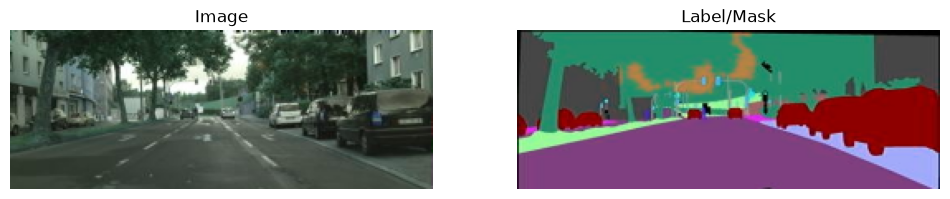

In [5]:
idx = 5
img = Image.open(os.path.join(train_img_dir, train_images[idx]))
label = Image.open(os.path.join(train_label_dir, train_labels[idx]))

fig, axes = plt.subplots(1, 2, figsize=(12, 6))
axes[0].imshow(img)
axes[0].set_title("Image")
axes[0].axis("off")

axes[1].imshow(label)
axes[1].set_title("Label/Mask")
axes[1].axis("off")

plt.show()


In [6]:
import torch
from torch.utils.data import Dataset, DataLoader
from torchvision import transforms


class CityscapesDataset(Dataset):
    def __init__(self, img_dir, label_dir, transform=None):
        self.img_dir = img_dir
        self.label_dir = label_dir
        self.images = sorted(os.listdir(img_dir))
        self.labels = sorted(os.listdir(label_dir))
        self.transform = transform

    def __len__(self):
        return len(self.images)

    def __getitem__(self, idx):
        img = Image.open(os.path.join(self.img_dir, self.images[idx])).convert("RGB")
        label = Image.open(os.path.join(self.label_dir, self.labels[idx]))

        if self.transform:
            img = self.transform(img)
            label = self.transform(label)

        return img, label


transform = transforms.Compose([
    transforms.Resize((256, 256)),
    transforms.ToTensor(),
])

train_dataset = CityscapesDataset(train_img_dir, train_label_dir, transform=transform)
val_dataset = CityscapesDataset(val_img_dir, val_label_dir, transform=transform)

train_loader = DataLoader(train_dataset, batch_size=8, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=8, shuffle=False)

imgs, labels = next(iter(train_loader))
print("Batch image shape:", imgs.shape)
print("Batch label shape:", labels.shape)


Batch image shape: torch.Size([8, 3, 256, 256])
Batch label shape: torch.Size([8, 3, 256, 256])
